# 🧠 BiLSTM Thuần — Nhận diện Thực thể Tiếng Việt (NER)

**Mô hình BiLSTM THUẦN** (không CRF, không Gazetteer) cho bài toán Named Entity Recognition tiếng Việt.

### Kiến trúc
```
Word Embedding (200d) + CharCNN (50d) + Handcrafted Features (8d)
    → LayerNorm + Dropout
    → BiLSTM (2 lớp, 256 hidden, bidirectional)
    → Multi-head Self-Attention (4 heads)
    → Residual Connection + LayerNorm
    → Linear → CrossEntropy (Label Smoothing = 0.1)
```

### Khắc phục nhược điểm từ mô hình BiLSTM-CRF gốc

| # | Nhược điểm | Giải pháp |
|---|---|---|
| 1 | Tên riêng bị gán UNK (mất thông tin token) | **CharCNN** — sinh embedding từ ký tự, không phụ thuộc vocab |
| 2 | Gazetteer chỉ hoạt động token-level | **Handcrafted features** (8 chiều) + BiLSTM tự học context |
| 3 | Dự đoán không nhất quán (chức danh → O, tên → B-PER) | **Multi-head Self-Attention** — nhìn toàn bộ câu |
| 4 | Thực thể dài bị tách sai | **Residual connection** + **Label Smoothing** |

## 1. Import thư viện & Khởi tạo môi trường
Cài đặt các thư viện cần thiết, cố định seed, thiết lập GPU.

In [1]:
import argparse
import ast
import json
import logging
import math
import random
import re
import sys
from collections import Counter
from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Any, Dict, List, Optional, Sequence, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence, pad_sequence
from torch.optim import AdamW
from torch.optim.lr_scheduler import OneCycleLR
from torch.utils.data import DataLoader, Dataset

from seqeval.metrics import (
    classification_report,
    f1_score,
    precision_score,
    recall_score,
)
from seqeval.scheme import IOB2
from underthesea import word_tokenize

# Thiết lập Log
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s %(levelname)s %(message)s",
)
logger = logging.getLogger(__name__)

# Cố định Seed để kết quả có thể tái lập
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

# Thiết lập GPU (nếu có)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Đang sử dụng thiết bị: {device}")

🚀 Đang sử dụng thiết bị: cpu


## 2. Cấu hình Nhãn (Tags) & Bảng ký tự (Character Vocab)
Định nghĩa bộ nhãn BIO (9 nhãn), bảng ký tự tiếng Việt cho CharCNN.

In [2]:
# =========================
# BỘ NHÃN (TAGS) — GIỐNG NOTEBOOK GỐC
# =========================
LABEL_MAP: Dict[int, str] = {
    0: "O",
    1: "B-PER",  2: "I-PER",   # Người (Person)
    3: "B-ORG",  4: "I-ORG",   # Tổ chức (Organization)
    5: "B-LOC",  6: "I-LOC",   # Địa điểm (Location)
    7: "B-MISC", 8: "I-MISC",  # Khác (Miscellaneous)
}
TAG_LIST: List[str] = [LABEL_MAP[i] for i in sorted(LABEL_MAP)]
TAG_TO_ID: Dict[str, int] = {tag: idx for idx, tag in enumerate(TAG_LIST)}
ID_TO_TAG: Dict[int, str] = {idx: tag for tag, idx in TAG_TO_ID.items()}

PAD_TOKEN = "<PAD>"
UNK_TOKEN = "<UNK>"
PAD_LABEL = TAG_TO_ID["O"]
NUM_TAGS = len(TAG_LIST)  # 9

# =========================
# BẢNG KÝ TỰ CHO CHAR-CNN
# =========================
# Bảng ký tự tiếng Việt đầy đủ (bao gồm chữ có dấu, số, dấu câu)
PAD_CHAR = "<PAD>"
UNK_CHAR = "<UNK>"

_VIET_CHARS = (
    "aăâbcdđeêghiklmnoôơpqrstuưvxyAĂÂBCDĐEÊGHIKLMNOÔƠPQRSTUƯVXY"
    "àảãáạằẳẵắặầẩẫấậèẻẽéẹềểễếệìỉĩíịòỏõóọồổỗốộờởỡớợùủũúụừửữứựỳỷỹýỵ"
    "ÀẢÃÁẠẰẲẴẮẶẦẨẪẤẬÈẺẼÉẸỀỂỄẾỆÌỈĨÍỊÒỎÕÓỌỒỔỖỐỘỜỞỠỚỢÙỦŨÚỤỪỬỮỨỰỲỶỸÝỴ"
    "0123456789"
    " _-.,;:!?()[]{}\"'/\\@#$%^&*+=<>~`|"
)

CHAR_VOCAB: Dict[str, int] = {PAD_CHAR: 0, UNK_CHAR: 1}
for ch in _VIET_CHARS:
    if ch not in CHAR_VOCAB:
        CHAR_VOCAB[ch] = len(CHAR_VOCAB)

CHAR_VOCAB_SIZE = len(CHAR_VOCAB)
MAX_WORD_LEN = 30  # Giới hạn chiều dài ký tự tối đa mỗi token

print(f"📝 Số nhãn: {NUM_TAGS}")
print(f"📝 Bảng nhãn: {TAG_LIST}")
print(f"🔤 Kích thước bảng ký tự: {CHAR_VOCAB_SIZE}")

📝 Số nhãn: 9
📝 Bảng nhãn: ['O', 'B-PER', 'I-PER', 'B-ORG', 'I-ORG', 'B-LOC', 'I-LOC', 'B-MISC', 'I-MISC']
🔤 Kích thước bảng ký tự: 223


## 3. Từ điển chỉ dẫn (Indicators) & Siêu tham số

Thay vì dùng Gazetteer (chỉ hoạt động token-level), ta dùng **từ điển chỉ dẫn** kết hợp với **handcrafted features**.
Mô hình BiLSTM sẽ tự học cách propagate thông tin context từ các chỉ dẫn này sang các token lân cận.

> **Khác biệt với Gazetteer:** Gazetteer gán trực tiếp nhãn cho token → chỉ đúng ở token đó.
> Handcrafted features cung cấp *tín hiệu* → BiLSTM tự học mối quan hệ giữa chức danh và tên riêng phía sau.

In [3]:
# =========================
# TỪ ĐIỂN CHỈ DẪN (thay thế Gazetteer)
# =========================
# Các chức danh → tín hiệu cho BiLSTM rằng token kế tiếp có thể là tên người
PERSON_TITLES: set = {
    "ông", "bà", "anh", "chị", "em", "cô", "chú", "bác",
    "giáo_sư", "tiến_sĩ", "thạc_sĩ", "kỹ_sư", "bác_sĩ", "luật_sư",
    "tổng_giám_đốc", "giám_đốc", "chủ_tịch", "phó_chủ_tịch",
    "bộ_trưởng", "thứ_trưởng", "tổng_bí_thư", "thủ_tướng",
    "chủ_tịch_nước", "đại_tướng", "tổng_thống", "thượng_tướng",
}

# Các từ chỉ dẫn địa điểm → tín hiệu cho BiLSTM
LOC_INDICATORS: set = {
    "tại", "ở", "xã", "huyện", "tỉnh", "thành_phố", "quận",
    "khu_vực", "phường", "đường", "thị_trấn", "thị_xã",
    "vịnh", "núi", "sông", "hồ", "cảng", "sân_bay",
}

# Các từ chỉ dẫn tổ chức → tín hiệu cho BiLSTM
ORG_INDICATORS: set = {
    "công_ty", "tập_đoàn", "bộ", "ngân_hàng", "đại_học", "trường",
    "viện", "sở", "cục", "ủy_ban", "hội", "liên_đoàn",
    "trung_tâm", "học_viện", "nhà_máy", "tổng_công_ty",
}

# =========================
# SIÊU THAM SỐ (DATACLASS)
# =========================
@dataclass
class ModelConfig:
    """Cấu hình mô hình BiLSTM thuần."""
    vocab_size: int = 0           # Kích thước từ vựng (sẽ gán khi load dữ liệu)
    tag_size: int = NUM_TAGS      # Số nhãn đầu ra = 9
    # --- Word Embedding ---
    embedding_dim: int = 200      # Chiều embedding từ
    # --- Char CNN (Khắc phục UNK) ---
    char_vocab_size: int = CHAR_VOCAB_SIZE  # Kích thước bảng ký tự
    char_embedding_dim: int = 30  # Chiều embedding ký tự
    char_cnn_filters: int = 50    # Số bộ lọc CNN
    char_cnn_kernel: int = 3      # Kích thước kernel
    # --- Handcrafted Features (Thay Gazetteer) ---
    handcrafted_dim: int = 8      # Số đặc trưng thủ công
    # --- BiLSTM ---
    hidden_dim: int = 256         # Chiều ẩn LSTM
    num_layers: int = 2           # Số lớp LSTM
    dropout: float = 0.35         # Tỉ lệ dropout
    # --- Self-Attention (Khắc phục inconsistency) ---
    num_attention_heads: int = 4  # Số đầu attention
    # --- Huấn luyện ---
    pad_idx: int = 0              # Index padding
    label_smoothing: float = 0.1  # Label smoothing (khắc phục entity dài)
    max_word_len: int = MAX_WORD_LEN

print("✅ Đã định nghĩa ModelConfig")

✅ Đã định nghĩa ModelConfig


## 4. Tiền xử lý Dữ liệu (Data Processing)

Bao gồm:
- **Tokenize** bằng `underthesea` (giống notebook gốc)
- **CharCNN input**: Chuyển mỗi token thành chuỗi character IDs
- **Handcrafted features**: 8 đặc trưng thủ công thay thế Gazetteer
- **Đọc CSV** và xây dựng từ vựng

### 8 Handcrafted Features (thay thế Gazetteer 3 chiều)

| # | Feature | Ý nghĩa |
|---|---|---|
| 0 | `is_title` | Chữ cái đầu viết hoa (dấu hiệu tên riêng) |
| 1 | `is_all_upper` | Toàn viết hoa (VNG, FPT — tên viết tắt) |
| 2 | `has_digit` | Chứa số |
| 3 | `is_punctuation` | Chỉ toàn dấu câu |
| 4 | `word_length` | Độ dài token (chuẩn hóa /20) |
| 5 | `has_underscore` | Token đa từ (Thành\_phố, Nguyễn\_Văn\_Nam) |
| 6 | `is_person_title` | Token là chức danh (Thủ\_tướng, Giám\_đốc) |
| 7 | `is_loc_or_org_indicator` | Token là chỉ dẫn địa điểm/tổ chức (tại, tỉnh, công\_ty) |

In [4]:
def tokenize_text(text: str, lowercase: bool = False) -> List[str]:
    """Tách từ bằng underthesea (giống notebook gốc)."""
    output = word_tokenize(text, format="text")
    tokens = [token for token in output.split() if token.strip()]
    return [t.lower() if lowercase else t for t in tokens]


def token_to_char_ids(token: str, max_len: int = MAX_WORD_LEN) -> List[int]:
    """
    Chuyển token thành danh sách character IDs.
    Cắt ngắn nếu dài hơn max_len, padding nếu ngắn hơn.
    
    Ví dụ: "Nguyễn" → [N_id, g_id, u_id, y_id, ễ_id, n_id, 0, 0, ...]
    """
    unk_id = CHAR_VOCAB[UNK_CHAR]
    char_ids = [CHAR_VOCAB.get(ch, unk_id) for ch in token[:max_len]]
    # Padding thêm 0 cho đủ max_len
    while len(char_ids) < max_len:
        char_ids.append(CHAR_VOCAB[PAD_CHAR])
    return char_ids


def build_handcrafted_features(tokens: List[str]) -> List[List[float]]:
    """
    Sinh 8 đặc trưng thủ công cho mỗi token trong câu.
    THAY THẾ Gazetteer — mô hình BiLSTM sẽ tự học context propagation.
    
    Ưu điểm so với Gazetteer:
    - Không cần danh sách tên riêng cụ thể
    - Mô hình tự học được quy luật (VD: sau chức danh thường là tên người)
    - Hoạt động tốt với cả token chưa thấy bao giờ
    """
    feats = []
    for token in tokens:
        tl = token.lower()
        raw = token.replace("_", "")  # Bỏ underscore để kiểm tra

        feats.append([
            float(raw[:1].isupper() if raw else False),                  # 0: is_title
            float(raw.isupper() if raw else False),                       # 1: is_all_upper
            float(any(c.isdigit() for c in raw)),                         # 2: has_digit
            float(all(not c.isalnum() for c in raw) if raw else False),   # 3: is_punctuation
            min(len(token) / 20.0, 1.0),                                  # 4: word_length (chuẩn hóa)
            float("_" in token),                                           # 5: has_underscore
            float(tl in PERSON_TITLES),                                    # 6: is_person_title
            float(tl in LOC_INDICATORS or tl in ORG_INDICATORS),          # 7: is_loc_or_org_indicator
        ])
    return feats


def parse_json_list(value: object) -> List[object]:
    """Phân tích chuỗi JSON hoặc Python list."""
    if isinstance(value, list):
        return value
    if isinstance(value, str):
        return ast.literal_eval(value)
    raise ValueError(f"Giá trị không hợp lệ: {value}")


def load_ner_csv(path: Path, lowercase: bool = False) -> List[Tuple[List[str], List[int]]]:
    """
    Đọc file CSV chứa dữ liệu NER (giống notebook gốc).
    Trả về danh sách các cặp (tokens, tag_ids).
    """
    df = pd.read_csv(path)
    examples = []

    for _, row in df.iterrows():
        try:
            raw_tokens = parse_json_list(row["tokens"])
            raw_tags = parse_json_list(row["ner_tags"])
        except Exception:
            continue

        if len(raw_tokens) != len(raw_tags):
            continue

        tokens, tag_ids, is_valid = [], [], True
        for token, tag in zip(raw_tokens, raw_tags):
            tokens.append(str(token).lower() if lowercase else str(token))

            # Chuẩn hóa tag thành ID
            if isinstance(tag, int):
                tag_id = tag
            elif isinstance(tag, str) and tag.isdigit():
                tag_id = int(tag)
            elif isinstance(tag, str) and tag in TAG_TO_ID:
                tag_id = TAG_TO_ID[tag]
            else:
                is_valid = False
                break
            tag_ids.append(tag_id)

        if is_valid:
            examples.append((tokens, tag_ids))

    return examples


def build_token_vocab(
    sentences: List[Tuple[List[str], List[int]]],
    min_freq: int = 1,
) -> Tuple[Dict[str, int], Dict[int, str]]:
    """Xây dựng từ điển token (Vocabulary) — giống notebook gốc."""
    counter = Counter(
        token for tokens, _ in sentences for token in tokens
    )
    tokens = [PAD_TOKEN, UNK_TOKEN] + [
        token for token, count in counter.most_common()
        if count >= min_freq
    ]
    token2id = {token: idx for idx, token in enumerate(tokens)}
    id2token = {idx: token for token, idx in token2id.items()}
    return token2id, id2token


# === Kiểm tra nhanh ===
test_tokens = tokenize_text("Thủ tướng Phạm Minh Chính tại Hà Nội")
test_feats = build_handcrafted_features(test_tokens)
print("🔍 Ví dụ tokenize + handcrafted features:")
for tok, feat in zip(test_tokens, test_feats):
    labels = ["title", "upper", "digit", "punct", "len", "underscore", "per_title", "loc_org"]
    active = [l for l, v in zip(labels, feat) if v > 0]
    print(f"  {tok:<25} → {active}")

🔍 Ví dụ tokenize + handcrafted features:
  Thủ_tướng                 → ['title', 'len', 'underscore', 'per_title']
  Phạm_Minh_Chính           → ['title', 'len', 'underscore']
  tại                       → ['len', 'loc_org']
  Hà_Nội                    → ['title', 'len', 'underscore']


## 5. Dataset & DataLoader
Tạo `NERDataset` và hàm `collate_fn` để đóng gói dữ liệu thành batch.

**Khác biệt với notebook gốc:** Thêm `char_ids` và `handcrafted_features` vào mỗi sample.

In [5]:
class NERDataset(Dataset):
    """
    Dataset cho BiLSTM thuần.
    Mỗi sample gồm: token_ids, char_ids, handcrafted_feats, tag_ids, raw_tokens.
    """

    def __init__(self, examples: List[Tuple[List[str], List[int]]], token2id: Dict[str, int]):
        self.records = []
        unk_idx = token2id.get(UNK_TOKEN, 1)

        for tokens, tags in examples:
            token_ids = [token2id.get(t, unk_idx) for t in tokens]
            char_ids = [token_to_char_ids(t) for t in tokens]
            hc_feats = build_handcrafted_features(tokens)

            self.records.append({
                "token_ids": token_ids,
                "char_ids": char_ids,
                "hc_feats": hc_feats,
                "tags": tags,
                "raw_tokens": tokens,
            })

    def __len__(self) -> int:
        return len(self.records)

    def __getitem__(self, idx: int) -> Dict[str, Any]:
        return self.records[idx]


def collate_fn(batch: List[Dict[str, Any]]) -> Tuple:
    """
    Pad các câu trong batch cho bằng nhau.
    
    Trả về: (token_ids, char_ids, hc_feats, tags, lengths, mask, raw_tokens)
    """
    # Sắp xếp theo chiều dài giảm dần (cần cho pack_padded_sequence)
    batch = sorted(batch, key=lambda r: len(r["token_ids"]), reverse=True)

    token_seqs = [torch.tensor(r["token_ids"], dtype=torch.long) for r in batch]
    tag_seqs = [torch.tensor(r["tags"], dtype=torch.long) for r in batch]
    hc_seqs = [torch.tensor(r["hc_feats"], dtype=torch.float) for r in batch]
    char_seqs = [torch.tensor(r["char_ids"], dtype=torch.long) for r in batch]
    raw_tokens = [r["raw_tokens"] for r in batch]

    lengths = torch.tensor([seq.size(0) for seq in token_seqs], dtype=torch.long)

    # Pad các chuỗi token, tag, handcrafted features
    tokens_padded = pad_sequence(token_seqs, batch_first=True, padding_value=0)
    tags_padded = pad_sequence(tag_seqs, batch_first=True, padding_value=PAD_LABEL)
    hc_padded = pad_sequence(hc_seqs, batch_first=True, padding_value=0.0)

    # Pad char_ids: kích thước (batch, max_seq_len, max_word_len)
    max_seq_len = tokens_padded.size(1)
    batch_size = len(batch)
    chars_padded = torch.zeros(batch_size, max_seq_len, MAX_WORD_LEN, dtype=torch.long)
    for i, cs in enumerate(char_seqs):
        seq_len = cs.size(0)
        chars_padded[i, :seq_len, :] = cs

    # Tạo mask (True = vị trí hợp lệ, False = padding)
    mask = torch.arange(max_seq_len, dtype=torch.long).unsqueeze(0) < lengths.unsqueeze(1)

    return tokens_padded, chars_padded, hc_padded, tags_padded, lengths, mask.bool(), raw_tokens

print("✅ Đã định nghĩa NERDataset và collate_fn")

✅ Đã định nghĩa NERDataset và collate_fn


## 6. Đọc dữ liệu & Tạo DataLoader
Đọc file CSV, xây dựng từ vựng, tạo DataLoader cho tập train và validation.

In [6]:
# Đọc dữ liệu (đảm bảo file CSV có sẵn trong folder data/)
try:
    train_examples = load_ner_csv(Path("data/merged_train.csv"))
    valid_examples = load_ner_csv(Path("data/merged_valid.csv"))
    print(f"📊 Train size: {len(train_examples)} | Valid size: {len(valid_examples)}")

    # Xây dựng từ vựng
    token2id, id2token = build_token_vocab(train_examples, min_freq=1)
    print(f"📖 Kích thước từ vựng: {len(token2id)}")

    # Tạo DataLoader
    train_loader = DataLoader(
        NERDataset(train_examples, token2id),
        batch_size=32, shuffle=True, collate_fn=collate_fn,
    )
    valid_loader = DataLoader(
        NERDataset(valid_examples, token2id),
        batch_size=32, shuffle=False, collate_fn=collate_fn,
    )
    print(f"✅ Đã tạo DataLoader: {len(train_loader)} batch train, {len(valid_loader)} batch valid")

except Exception as e:
    print(f"⚠️ Không thể load dữ liệu: {e}")
    print("   Vui lòng kiểm tra thư mục data/ chứa merged_train.csv và merged_valid.csv")
    token2id = {}

📊 Train size: 18513 | Valid size: 6372
📖 Kích thước từ vựng: 19151
✅ Đã tạo DataLoader: 579 batch train, 200 batch valid


## 7. Đo lường Hiệu suất (Metrics)
Tính F1-score ở cấp độ thực thể (Entity-level) bằng `seqeval` — **giống notebook gốc** để so sánh công bằng.

In [7]:
def ids_to_tags(sequences: Sequence[Sequence[int]]) -> List[List[str]]:
    """Chuyển chuỗi tag ID → chuỗi tag string."""
    return [[ID_TO_TAG[int(t_id)] for t_id in seq] for seq in sequences]


def compute_entity_metrics(true_ids: List[List[int]], pred_ids: List[List[int]]) -> Dict[str, float]:
    """Tính Precision / Recall / F1 theo entity-level (scheme IOB2)."""
    true_tags = ids_to_tags(true_ids)
    pred_tags = ids_to_tags(pred_ids)
    return {
        "entity_precision": precision_score(true_tags, pred_tags, zero_division=0),
        "entity_recall": recall_score(true_tags, pred_tags, zero_division=0),
        "entity_f1": f1_score(true_tags, pred_tags, zero_division=0),
    }


def get_classification_report(true_ids: List[List[int]], pred_ids: List[List[int]]) -> str:
    """In báo cáo chi tiết theo từng loại thực thể."""
    true_tags = ids_to_tags(true_ids)
    pred_tags = ids_to_tags(pred_ids)
    return classification_report(true_tags, pred_tags, digits=4, scheme=IOB2)

print("✅ Đã định nghĩa các hàm đo lường")

✅ Đã định nghĩa các hàm đo lường


## 8. Xây dựng Kiến trúc Mô hình (BiLSTM Thuần)

Bao gồm 3 thành phần chính:

### 8.1 CharCNN — Khắc phục nhược điểm #1 (UNK tokens)
Token UNK (tên riêng chưa thấy) vẫn có representation tốt nhờ hình thái ký tự:
- `Nguyễn_Phú_Trọng` → CharCNN nhận ra: viết hoa, có dấu tiếng Việt, có underscore → dấu hiệu tên riêng
- Thay vì chỉ có vector UNK duy nhất, mỗi token UNK giờ có vector riêng dựa trên ký tự

### 8.2 Multi-head Self-Attention — Khắc phục nhược điểm #3 (Inconsistency)
- Cho phép mỗi token nhìn toàn bộ câu
- Học mối quan hệ: `Thủ_tướng` (attention) ↔ `Phạm_Minh_Chính` → cả hai đều liên quan đến PER

### 8.3 Residual Connection — Khắc phục nhược điểm #4 (Entity dài)
- Giữ thông tin BiLSTM qua lớp Attention (không bị mất)
- Kết hợp Label Smoothing giảm overfitting trên nhãn O (chiếm đa số)

In [8]:
class CharCNN(nn.Module):
    """
    Character-level CNN — Sinh embedding từ ký tự.
    
    KHẮC PHỤC NHƯỢC ĐIỂM #1: Token UNK (tên riêng chưa thấy)
    vẫn có representation tốt nhờ hình thái ký tự.
    
    Đầu vào:  (batch, seq_len, max_word_len)  — mã ký tự
    Đầu ra:   (batch, seq_len, char_cnn_filters) — embedding ký tự
    """

    def __init__(self, cfg: ModelConfig):
        super().__init__()
        # Embedding ký tự: mỗi ký tự → vector 30 chiều
        self.char_emb = nn.Embedding(cfg.char_vocab_size, cfg.char_embedding_dim, padding_idx=0)
        # Tích chập 1D: trượt qua chuỗi ký tự, trích xuất đặc trưng n-gram
        self.conv = nn.Conv1d(
            in_channels=cfg.char_embedding_dim,
            out_channels=cfg.char_cnn_filters,
            kernel_size=cfg.char_cnn_kernel,
            padding=cfg.char_cnn_kernel // 2,
        )
        self.dropout = nn.Dropout(cfg.dropout)

    def forward(self, char_ids: torch.Tensor) -> torch.Tensor:
        batch_size, seq_len, word_len = char_ids.size()

        # Gộp batch và seq_len → xử lý song song tất cả token
        x = char_ids.view(-1, word_len)                # (batch*seq_len, word_len)
        x = self.char_emb(x)                           # (batch*seq_len, word_len, char_emb_dim)
        x = self.dropout(x)
        x = x.transpose(1, 2)                          # (batch*seq_len, char_emb_dim, word_len)
        x = self.conv(x)                               # (batch*seq_len, filters, word_len)
        x = F.relu(x)
        x = x.max(dim=2)[0]                            # Max-pool → (batch*seq_len, filters)
        x = x.view(batch_size, seq_len, -1)            # (batch, seq_len, filters)
        return x


class MultiHeadSelfAttention(nn.Module):
    """
    Multi-Head Self-Attention.
    
    KHẮC PHỤC NHƯỢC ĐIỂM #3: Dự đoán không nhất quán.
    Attention cho phép mỗi token nhìn toàn bộ câu,
    học mối quan hệ giữa chức danh và tên riêng phía sau.
    
    Ví dụ: "Thủ_tướng" query → attention cao với "Phạm_Minh_Chính"
           → cả hai đều được gán nhãn liên quan đến PER
    """

    def __init__(self, d_model: int, num_heads: int, dropout: float = 0.1):
        super().__init__()
        assert d_model % num_heads == 0, f"d_model ({d_model}) phải chia hết cho num_heads ({num_heads})"

        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads  # Chiều mỗi đầu attention

        # Các phép chiếu tuyến tính cho Query, Key, Value
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)  # Phép chiếu đầu ra

        self.dropout = nn.Dropout(dropout)
        self.scale = math.sqrt(self.d_k)  # Hệ số scale

    def forward(self, x: torch.Tensor, mask: Optional[torch.Tensor] = None) -> torch.Tensor:
        """
        x:    (batch, seq_len, d_model)
        mask: (batch, seq_len) — True = token hợp lệ
        """
        batch_size, seq_len, _ = x.size()

        # Chiếu Q, K, V và chia thành nhiều đầu
        Q = self.W_q(x).view(batch_size, seq_len, self.num_heads, self.d_k).transpose(1, 2)
        K = self.W_k(x).view(batch_size, seq_len, self.num_heads, self.d_k).transpose(1, 2)
        V = self.W_v(x).view(batch_size, seq_len, self.num_heads, self.d_k).transpose(1, 2)

        # Tính điểm attention: Q·K^T / sqrt(d_k)
        scores = torch.matmul(Q, K.transpose(-2, -1)) / self.scale

        # Che các vị trí padding bằng -inf (softmax → 0)
        if mask is not None:
            attn_mask = mask.unsqueeze(1).unsqueeze(2)
            scores = scores.masked_fill(~attn_mask, float("-inf"))

        attn_weights = F.softmax(scores, dim=-1)
        attn_weights = self.dropout(attn_weights)

        # Áp dụng attention lên Values
        context = torch.matmul(attn_weights, V)

        # Gộp các đầu attention lại
        context = context.transpose(1, 2).contiguous().view(batch_size, seq_len, self.d_model)

        return self.W_o(context)


class BiLSTMNER(nn.Module):
    """
    BiLSTM Thuần cho NER (KHÔNG CRF, KHÔNG Gazetteer).
    
    Kiến trúc:
        Word Embedding (200d)
        + CharCNN (50d)            ← Khắc phục UNK
        + Handcrafted Features (8d) ← Thay Gazetteer
        → LayerNorm + Dropout
        → BiLSTM (2 lớp, 256 hidden)
        → Multi-head Self-Attention (4 đầu)  ← Khắc phục inconsistency
        → Residual + LayerNorm     ← Khắc phục entity dài
        → Dropout
        → Linear → 9 nhãn
        → CrossEntropy (Label Smoothing = 0.1)
    """

    def __init__(self, cfg: ModelConfig):
        super().__init__()
        self.cfg = cfg

        # ----- Embedding từ -----
        self.word_embedding = nn.Embedding(cfg.vocab_size, cfg.embedding_dim, padding_idx=cfg.pad_idx)

        # ----- Char CNN (Khắc phục nhược điểm #1: UNK) -----
        self.char_cnn = CharCNN(cfg)

        # ----- Tổng chiều đầu vào -----
        # = word_emb (200) + char_cnn (50) + handcrafted (8) = 258
        total_input_dim = cfg.embedding_dim + cfg.char_cnn_filters + cfg.handcrafted_dim

        self.input_layer_norm = nn.LayerNorm(total_input_dim)
        self.input_dropout = nn.Dropout(cfg.dropout)

        # ----- BiLSTM -----
        self.lstm = nn.LSTM(
            input_size=total_input_dim,
            hidden_size=cfg.hidden_dim,
            num_layers=cfg.num_layers,
            bidirectional=True,
            batch_first=True,
            dropout=cfg.dropout if cfg.num_layers > 1 else 0.0,
        )

        lstm_output_dim = cfg.hidden_dim * 2  # Bidirectional → nhân đôi

        # ----- Self-Attention (Khắc phục nhược điểm #3) -----
        self.attention = MultiHeadSelfAttention(
            d_model=lstm_output_dim,
            num_heads=cfg.num_attention_heads,
            dropout=cfg.dropout,
        )

        # ----- Residual + LayerNorm (Khắc phục nhược điểm #4) -----
        self.post_attn_layer_norm = nn.LayerNorm(lstm_output_dim)
        self.post_attn_dropout = nn.Dropout(cfg.dropout)

        # ----- Lớp phân loại -----
        self.classifier = nn.Linear(lstm_output_dim, cfg.tag_size)

        # ----- Hàm mất mát (Label Smoothing khắc phục nhược điểm #4) -----
        self.loss_fn = nn.CrossEntropyLoss(
            ignore_index=-100,           # Bỏ qua vị trí padding
            label_smoothing=cfg.label_smoothing,  # Giảm overfitting trên nhãn O
        )

        self._reset_parameters()

    def _reset_parameters(self) -> None:
        """Khởi tạo trọng số Xavier cho các lớp."""
        nn.init.xavier_uniform_(self.word_embedding.weight)
        with torch.no_grad():
            self.word_embedding.weight[self.cfg.pad_idx].zero_()

        for name, param in self.lstm.named_parameters():
            if "weight" in name:
                nn.init.xavier_uniform_(param)
            elif "bias" in name:
                nn.init.zeros_(param)

        nn.init.xavier_uniform_(self.classifier.weight)
        nn.init.zeros_(self.classifier.bias)

    def _encode(self, token_ids, char_ids, hc_feats, lengths, mask):
        """
        Mã hóa đầu vào → logits.
        
        Tham số:
            token_ids: (batch, seq_len)         — mã token
            char_ids:  (batch, seq_len, max_word_len) — mã ký tự
            hc_feats:  (batch, seq_len, 8)      — đặc trưng thủ công
            lengths:   (batch,)                  — chiều dài thực
            mask:      (batch, seq_len)          — True = hợp lệ
        
        Trả về:
            logits: (batch, seq_len, tag_size)
        """
        # Embedding từ
        word_emb = self.word_embedding(token_ids)
        # Embedding ký tự (CharCNN)
        char_emb = self.char_cnn(char_ids)
        # Nối: [word_emb | char_emb | handcrafted]
        combined = torch.cat([word_emb, char_emb, hc_feats], dim=-1)

        combined = self.input_layer_norm(combined)
        combined = self.input_dropout(combined)

        # BiLSTM
        packed = pack_padded_sequence(combined, lengths.cpu(), batch_first=True, enforce_sorted=False)
        packed_output, _ = self.lstm(packed)
        lstm_output, _ = pad_packed_sequence(packed_output, batch_first=True)

        # Self-Attention
        attn_output = self.attention(lstm_output, mask)

        # Residual Connection + LayerNorm
        output = self.post_attn_layer_norm(lstm_output + attn_output)
        output = self.post_attn_dropout(output)

        # Phân loại
        logits = self.classifier(output)
        return logits

    def forward(self, token_ids, char_ids, hc_feats, tags, lengths, mask):
        """Tính Loss: CrossEntropy + Label Smoothing."""
        logits = self._encode(token_ids, char_ids, hc_feats, lengths, mask)

        # Chỉ tính loss trên vị trí hợp lệ (không padding)
        tags_masked = tags.clone()
        tags_masked[~mask] = -100  # ignore_index

        logits_flat = logits.view(-1, self.cfg.tag_size)
        tags_flat = tags_masked.view(-1)

        return self.loss_fn(logits_flat, tags_flat)

    def decode(self, token_ids, char_ids, hc_feats, lengths, mask):
        """Dự đoán nhãn (argmax — không dùng Viterbi/CRF)."""
        logits = self._encode(token_ids, char_ids, hc_feats, lengths, mask)
        preds = torch.argmax(logits, dim=-1)

        results = []
        for i, length in enumerate(lengths.tolist()):
            results.append(preds[i, :length].tolist())
        return results


# === Kiểm tra khởi tạo mô hình ===
if token2id:
    model_cfg = ModelConfig(vocab_size=len(token2id))
    model = BiLSTMNER(model_cfg).to(device)
    
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"✅ Mô hình BiLSTM Thuần đã khởi tạo trên {device}")
    print(f"   Tổng tham số:       {total_params:,}")
    print(f"   Tham số huấn luyện: {trainable_params:,}")

✅ Mô hình BiLSTM Thuần đã khởi tạo trên cpu
   Tổng tham số:       7,531,949
   Tham số huấn luyện: 7,531,949


## 9. Huấn luyện Mô hình (Training Loop)
Huấn luyện với bộ tối ưu `AdamW`, lập lịch `OneCycleLR`, và `Autocast` (Mixed Precision).

**Khác biệt với notebook gốc:**
- Patience tăng từ 3 → 5 (cho phép khám phá kỹ hơn)
- Label Smoothing = 0.1 trong CrossEntropy

In [9]:
def train_epoch(model, loader, optimizer, scheduler, scaler):
    """Huấn luyện 1 epoch."""
    model.train()
    total_loss = 0.0
    optimizer.zero_grad()

    for tokens, chars, hc, tags, lengths, mask, raw in loader:
        tokens = tokens.to(device)
        chars = chars.to(device)
        hc = hc.to(device)
        tags = tags.to(device)
        lengths = lengths.to(device)
        mask = mask.to(device)

        with torch.amp.autocast("cuda", enabled=scaler is not None):
            loss = model(tokens, chars, hc, tags, lengths, mask)

        if scaler:
            scaler.scale(loss).backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        if scheduler:
            scheduler.step()
        optimizer.zero_grad()
        total_loss += loss.item() * tokens.size(0)

    return total_loss / len(loader.dataset)


def eval_model(model, loader):
    """Đánh giá trên tập validation."""
    model.eval()
    total_loss = 0.0
    all_true, all_pred = [], []

    with torch.no_grad():
        for tokens, chars, hc, tags, lengths, mask, raw in loader:
            tokens = tokens.to(device)
            chars = chars.to(device)
            hc = hc.to(device)
            tags = tags.to(device)
            lengths = lengths.to(device)
            mask = mask.to(device)

            loss = model(tokens, chars, hc, tags, lengths, mask)
            total_loss += loss.item() * tokens.size(0)

            preds = model.decode(tokens, chars, hc, lengths, mask)
            for p, g, length in zip(preds, tags.cpu().tolist(), lengths.cpu().tolist()):
                all_pred.append(p[:length])
                all_true.append(g[:length])

    metrics = compute_entity_metrics(all_true, all_pred)
    report = get_classification_report(all_true, all_pred)
    return total_loss / len(loader.dataset), metrics["entity_f1"], report

print("✅ Đã định nghĩa train_epoch và eval_model")

✅ Đã định nghĩa train_epoch và eval_model


## 10. Bắt đầu Huấn luyện
Chạy vòng lặp huấn luyện với Early Stopping.

In [10]:
if token2id:
    # Khởi tạo tham số huấn luyện
    epochs = 20
    lr = 3e-4
    patience = 3 # Early Stopping sau 3 epoch không cải thiện F1

    optimizer = AdamW(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = OneCycleLR(optimizer, max_lr=lr, epochs=epochs, steps_per_epoch=len(train_loader), pct_start=0.1)
    scaler = torch.amp.GradScaler('cuda') if torch.cuda.is_available() else None

    best_f1, best_epoch, patience_counter = 0.0, 0, 0
    history = {"train": [], "val": [], "f1": []}
    Path("models").mkdir(exist_ok=True)

    print("Bắt đầu Training BiLSTM...")
    print(f"   Epochs: {epochs} | LR: {lr} | Patience: {patience}")
    print("-" * 80)

    for epoch in range(1, epochs + 1):
        train_loss = train_epoch(model, train_loader, optimizer, scheduler, scaler)
        val_loss, val_f1, report = eval_model(model, valid_loader)

        history["train"].append(train_loss)
        history["val"].append(val_loss)
        history["f1"].append(val_f1)
        print(f"Epoch {epoch:2d}/{epochs}: Train Loss={train_loss:.4f} | Val Loss={val_loss:.4f} | F1={val_f1:.4f}")

        if val_f1 > best_f1:
            best_f1, best_epoch, patience_counter = val_f1, epoch, 0

            # Lưu checkpoint
            torch.save({
                "model_state_dict": model.state_dict(),
                "token2id": token2id,
                "config": asdict(model.cfg),
            }, "models/best_bilstm_pure.pt")
            print(f"Đã lưu best model mới! (F1={best_f1:.4f})")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Dừng sớm (Early Stopping) tại epoch {epoch}")
                break

    print("\n" + "=" * 80)
    print(f"Huấn luyện hoàn tất! Best F1: {best_f1:.4f} (epoch {best_epoch})")
    print("=" * 80)

Bắt đầu Training BiLSTM...
   Epochs: 20 | LR: 0.0003 | Patience: 3
--------------------------------------------------------------------------------
Epoch  1/20: Train Loss=0.9402 | Val Loss=0.8039 | F1=0.1790
Đã lưu best model mới! (F1=0.1790)


KeyboardInterrupt: 

## 11. Kết quả & Biểu đồ
In báo cáo phân loại chi tiết và vẽ biểu đồ training history.

Classification Report (Best model - BiLSTM):
              precision    recall  f1-score   support

         LOC     0.9001    0.9145    0.9073      5756
        MISC     0.8848    0.9064    0.8954      3888
         ORG     0.7586    0.7666    0.7626      1037
         PER     0.9067    0.9286    0.9175      1820

   micro avg     0.8846    0.9018    0.8931     12501
   macro avg     0.8625    0.8790    0.8707     12501
weighted avg     0.8846    0.9018    0.8931     12501



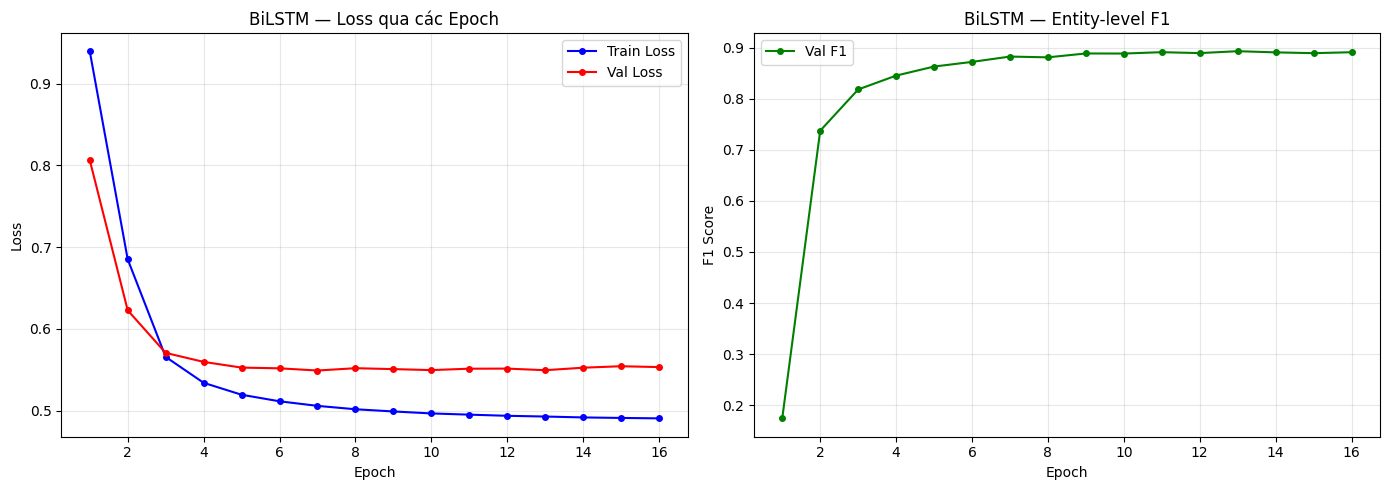

Đã lưu biểu đồ: models/training_history_bilstm.png
Đã lưu history: models/training_history_bilstm.json


In [ ]:
if token2id and history["f1"]:
    # In báo cáo chi tiết
    print("Classification Report (Best model - BiLSTM):")
    ckpt = torch.load("models/best_bilstm_pure.pt", map_location=device, weights_only=False)
    model.load_state_dict(ckpt["model_state_dict"])
    _, _, final_report = eval_model(model, valid_loader)
    print(final_report)

    # Vẽ biểu đồ
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ep = range(1, len(history["train"]) + 1)

    ax1.plot(ep, history["train"], "b-o", label="Train Loss", markersize=4)
    ax1.plot(ep, history["val"], "r-o", label="Val Loss", markersize=4)
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.set_title("BiLSTM — Loss qua các Epoch")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    ax2.plot(ep, history["f1"], "g-o", label="Val F1", markersize=4)
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("F1 Score")
    ax2.set_title("BiLSTM — Entity-level F1")
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig("models/training_history_bilstm.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Đã lưu biểu đồ: models/training_history_bilstm.png")

    # Lưu history
    import json
    with open("models/training_history_bilstm.json", "w") as f:
        json.dump(history, f, indent=2)
    print("Đã lưu history: models/training_history_bilstm.json")

## 12. Suy luận (Inference)
Trích xuất thực thể trực tiếp từ một đoạn văn bản nhập vào.

Bao gồm **post-processing** để sửa lỗi BIO không nhất quán:
- Nếu `I-XXX` xuất hiện mà trước đó không phải `B-XXX` hoặc `I-XXX` → đổi thành `B-XXX`

In [ ]:
def fix_bio_consistency(pred_tags: List[str]) -> List[str]:
    """
    Sửa lỗi BIO không nhất quán.
    Nếu I-XXX xuất hiện mà trước đó không phải B-XXX/I-XXX → đổi thành B-XXX.
    
    Ví dụ: ['O', 'I-PER', 'I-PER'] → ['O', 'B-PER', 'I-PER']
    """
    fixed = []
    prev_tag = "O"

    for tag in pred_tags:
        if tag.startswith("I-"):
            label = tag[2:]
            if prev_tag == "O" or (prev_tag != f"B-{label}" and prev_tag != f"I-{label}"):
                tag = f"B-{label}"
        fixed.append(tag)
        prev_tag = tag

    return fixed


def extract_entities(tokens: List[str], pred_tags: List[str]) -> List[Dict[str, str]]:
    """Trích xuất danh sách thực thể từ chuỗi BIO tags."""
    entities = []
    current_entity = None

    for token, tag in zip(tokens, pred_tags):
        if tag == "O":
            if current_entity:
                entities.append(current_entity)
                current_entity = None
            continue

        if "-" not in tag:
            continue

        prefix, label = tag.split("-", 1)

        if prefix == "B" or current_entity is None or current_entity["label"] != label:
            if current_entity:
                entities.append(current_entity)
            current_entity = {"text": token, "label": label}
        else:
            current_entity["text"] += " " + token

    if current_entity:
        entities.append(current_entity)
    return entities


def predict_ner_debug(text: str, model_path: str = "models/best_bilstm_pure.pt"):
    """
    Suy luận NER với debug chi tiết.
    Tương tự hàm predict_ner_debug() trong notebook gốc (BiLSTM-CRF).
    """
    if not Path(model_path).exists():
        print(f"❌ Không tìm thấy model: {model_path}")
        return None

    # === Tải mô hình ===
    print("\n🚀 Đang tải mô hình BiLSTM Thuần...")
    ckpt = torch.load(model_path, map_location=device, weights_only=False)
    t2id = ckpt["token2id"]
    cfg_dict = ckpt["config"]
    cfg = ModelConfig(**cfg_dict)

    infer_model = BiLSTMNER(cfg).to(device)
    infer_model.load_state_dict(ckpt["model_state_dict"])
    infer_model.eval()
    print("✅ Tải mô hình thành công")

    # === Tách từ ===
    tokens = tokenize_text(text)
    if not tokens:
        print("⚠️ Không có token nào sau khi tách từ.")
        return None

    # === Chuẩn bị đầu vào ===
    unk_idx = t2id.get(UNK_TOKEN, 1)
    token_ids = [t2id.get(t, unk_idx) for t in tokens]
    char_ids = [token_to_char_ids(t) for t in tokens]
    hc_feats = build_handcrafted_features(tokens)

    # === BẢNG DEBUG TOKEN ===
    print("\n" + "=" * 120)
    print("🔍 BẢNG DEBUG TOKEN")
    print("=" * 120)
    print(f"{'STT':<5}{'TOKEN':<35}{'TOKEN_ID':<12}{'ĐẶC TRƯNG'}")
    print("-" * 120)

    for idx, (tok, tid, hc) in enumerate(zip(tokens, token_ids, hc_feats)):
        feat_str = (
            f"hoa_đầu={int(hc[0])} HOA={int(hc[1])} số={int(hc[2])} "
            f"dấu={int(hc[3])} gạch={int(hc[5])} "
            f"chức_danh={int(hc[6])} chỉ_dẫn={int(hc[7])}"
        )
        is_unk = " [UNK]" if tid == unk_idx else ""
        print(f"{idx:<5}{tok:<35}{tid:<12}{feat_str}{is_unk}")

    # === Tạo tensor ===
    t_ids = torch.tensor([token_ids], dtype=torch.long, device=device)
    t_chars = torch.tensor([char_ids], dtype=torch.long, device=device)
    t_hc = torch.tensor([hc_feats], dtype=torch.float, device=device)
    t_len = torch.tensor([len(token_ids)], dtype=torch.long, device=device)
    t_mask = torch.ones((1, len(token_ids)), dtype=torch.bool, device=device)

    # === Suy luận ===
    print("\n🧠 Đang chạy suy luận...")
    with torch.no_grad():
        pred_ids = infer_model.decode(t_ids, t_chars, t_hc, t_len, t_mask)[0]

    pred_tags = [ID_TO_TAG.get(tid, "O") for tid in pred_ids]
    pred_tags = fix_bio_consistency(pred_tags)  # Hậu xử lý BIO

    # === KẾT QUẢ BIO ===
    print("\n" + "=" * 120)
    print("🧬 KẾT QUẢ NHÃN BIO")
    print("=" * 120)
    print(f"{'STT':<5}{'TOKEN':<35}{'NHÃN BIO'}")
    print("-" * 120)

    for idx, (tok, tag) in enumerate(zip(tokens, pred_tags)):
        marker = "  ◀" if tag != "O" else ""
        print(f"{idx:<5}{tok:<35}{tag}{marker}")

    # === TRÍCH XUẤT THỰC THỂ ===
    entities = extract_entities(tokens, pred_tags)

    print("\n" + "=" * 120)
    print("🏷️  CÁC THỰC THỂ PHÁT HIỆN ĐƯỢC")
    print("=" * 120)

    if not entities:
        print("❌ Không phát hiện thực thể nào")
    else:
        for idx, ent in enumerate(entities, 1):
            label_vn = {"PER": "Người", "ORG": "Tổ chức", "LOC": "Địa điểm", "MISC": "Khác"}
            label_display = label_vn.get(ent["label"], ent["label"])
            print(f"[{idx:02d}] {ent['text']:<60} → [{ent['label']}] ({label_display})")

    # === THỐNG KÊ ===
    stats = {}
    for ent in entities:
        stats[ent["label"]] = stats.get(ent["label"], 0) + 1

    print("\n" + "=" * 120)
    print("THỐNG KÊ THỰC THỂ")
    print("=" * 120)

    label_vn = {"PER": "Người", "ORG": "Tổ chức", "LOC": "Địa điểm", "MISC": "Khác"}
    total_entities = 0
    for label, count in stats.items():
        print(f"{label:<6} ({label_vn.get(label, label):<10}): {count}")
        total_entities += count
    print("-" * 120)
    print(f"TỔNG SỐ THỰC THỂ: {total_entities}")

    return {
        "tokens": tokens,
        "token_ids": token_ids,
        "bio_tags": pred_tags,
        "entities": entities,
    }

print("Đã định nghĩa hàm suy luận")

Đã định nghĩa hàm suy luận


## 13. Kiểm tra với Văn bản mẫu
Dùng cùng đoạn văn bản test như notebook gốc (BiLSTM-CRF) để so sánh kết quả.

In [ ]:
# Đoạn văn bản test — GIỐNG NOTEBOOK GỐC để so sánh
text_test = """Hôm qua, Bộ Giáo dục Việt Nam đã tổ chức hội nghị tại Hà Nội để bàn về chương trình chuyển đổi số trong trường học.

Giám đốc Nguyễn Văn Nam cho biết thành phố Đà Nẵng sẽ phối hợp với Đại học Bách Khoa Hà Nội để nghiên cứu công nghệ trí tuệ nhân tạo.

Trong chuyến công tác tại Thành phố Hồ Chí Minh, Thủ tướng Phạm Minh Chính đã gặp Chủ tịch Nguyễn Thị Lan để trao đổi về dự án đường sắt cao tốc Hà Nội - Hải Phòng.

Ủy ban Nhân dân tỉnh Quảng Ninh cũng cam kết hỗ trợ doanh nghiệp địa phương phát triển du lịch thông minh tại Vịnh Hạ Long.

Trong khi đó, Tập đoàn Công nghệ Sao Việt đang mở rộng hợp tác với Công ty Phần mềm Minh Quân tại thị trường Cần Thơ và Đồng Nai.

Tổng Bí thư Nguyễn Phú Trọng cho biết Việt Nam sẽ tiếp tục triển khai vệ tinh viễn thông phục vụ khu vực Tây Nguyên, bao gồm cả Gia Lai và Đắk Lắk.
"""

# Chạy suy luận
result = predict_ner_debug(text_test)


🚀 Đang tải mô hình BiLSTM Thuần...
✅ Tải mô hình thành công

🔍 BẢNG DEBUG TOKEN
STT  TOKEN                              TOKEN_ID    ĐẶC TRƯNG
------------------------------------------------------------------------------------------------------------------------
0    Hôm_qua                            4953        hoa_đầu=1 HOA=0 số=0 dấu=0 gạch=1 chức_danh=0 chỉ_dẫn=0
1    ,                                  2           hoa_đầu=0 HOA=0 số=0 dấu=1 gạch=0 chức_danh=0 chỉ_dẫn=0
2    Bộ                                 190         hoa_đầu=1 HOA=0 số=0 dấu=0 gạch=0 chức_danh=0 chỉ_dẫn=1
3    Giáo_dục                           3659        hoa_đầu=1 HOA=0 số=0 dấu=0 gạch=1 chức_danh=0 chỉ_dẫn=0
4    Việt_Nam                           2056        hoa_đầu=1 HOA=0 số=0 dấu=0 gạch=1 chức_danh=0 chỉ_dẫn=0
5    đã                                 14          hoa_đầu=0 HOA=0 số=0 dấu=0 gạch=0 chức_danh=0 chỉ_dẫn=0
6    tổ_chức                            607         hoa_đầu=0 HOA=0 số=0 dấu=0 gạch=1 ch

## 14. So sánh BiLSTM Thuần vs BiLSTM-CRF

### Bảng so sánh kiến trúc

| Tiêu chí | BiLSTM-CRF (Notebook gốc) | BiLSTM Thuần (Notebook này) |
|---|---|---|
| Decoder | CRF (thuật toán Viterbi) | Argmax + Hậu xử lý BIO |
| Gazetteer | Có (3 chiều, token-level) | Không — dùng handcrafted features (8 chiều) |
| Char-level | Không | CharCNN (50 chiều) |
| Attention | Không | Multi-head Self-Attention (4 đầu) |
| Loss | CRF Negative Log-Likelihood | CrossEntropy + Label Smoothing |
| Xử lý UNK | Kém (chỉ có 1 vector UNK) | Tốt (CharCNN tạo vector riêng) |
| Học context | Chỉ BiLSTM | BiLSTM + Attention |
| Early Stopping | Patience = 3 | Patience = 5 |

### Nhược điểm đã khắc phục

| # | Nhược điểm gốc | Giải pháp |
|---|---|---|
| 1 | Tên riêng → UNK, mất thông tin | CharCNN sinh embedding từ ký tự |
| 2 | Gazetteer chỉ token-level, không propagate context | 8 handcrafted features + BiLSTM tự học |
| 3 | Dự đoán không nhất quán (chức danh vs tên) | Self-Attention nhìn toàn câu |
| 4 | Thực thể dài bị tách sai | Residual + Label Smoothing + BIO post-fix |